# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




## Progress Log

| Week | Query Submitted (x1–x8) | Output (y) | Best y So Far | Acquisition / Strategy |
|---|---|---|---|---|
| Week 1 | 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351 | 9.888207 | 9.888207 | GP (RBF, fixed hyperparameters) + UCB (β=2.0), candidate search over 10,000-point Latin Hypercube — exploration-heavy |
| Week 2 | 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999 | 9.939383 | 9.939383 | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.5), next point via multi-start L-BFGS-B — shifting toward exploitation |
| Week 3 | 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000 | 9.933047 | 9.939383 *(Week 3 slightly underperformed Week 2's incumbent)* | GP (RBF, ARD, hyperparameters optimised) + UCB (β=1.0), multi-start L-BFGS-B — further exploitation |
| Week 4 | - | - | - | GP (RBF, ARD, hyperparameters optimised) + UCB (β=0.7), multi-start L-BFGS-B - exploitation continues, tempered because Week 3 did **not** beat Week 2, a signal not to over-commit to a single narrow region yet |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from plotting_utils import (plot_2d_function, plot_2d_bo_state, plot_convergence, plot_parallel_coordinates)

# Load and Analyse the Data

In [9]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [11]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.093998, 0.081832, 0.154891, 0.104133, 0.912141, 0.345036, 0.011181, 0.477351 ]   , dtype = np.float64)    # from input.txt
Y_w1_new_point = np.array([9.8882074579574], dtype = np.float64)    # from output.txt

# New data from Week 2 submission
X_w2_new_point = np.array([0.173855, 0.145601, 0.141754, 0.086242, 0.999999, 0.457141, 0.260715, 0.999999]   , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([9.9393827383054]                                                                  , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.13053 , 0.145043, 0.199622, 0.056929, 0.701352, 0.471131, 0.191028, 0.]         , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([9.933047259977]                                                                   , dtype=np.float64)    # from output.txt

In [13]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point
                              ])

In [15]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [17]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated


# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

Input  Shape: (43, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [19]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         Y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [22]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  43.000000  43.000000  43.000000  43.000000  43.000000  43.000000   
mean    0.506575   0.447871   0.491513   0.406169   0.497012   0.457636   
std     0.316906   0.311732   0.286850   0.267511   0.292217   0.267869   
min     0.009077   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.177078   0.145322   0.263873   0.140911   0.243904   0.248903   
50%     0.506028   0.482734   0.420888   0.424597   0.480619   0.410105   
75%     0.785353   0.676618   0.728788   0.650684   0.732423   0.680609   
max     0.985945   0.973980   0.998885   0.902986   0.999999   0.990244   

             X_7        X_8          Y  
count  43.000000  43.000000  43.000000  
mean    0.549552   0.505725   7.962131  
std     0.273043   0.292282   1.071620  
min     0.011181   0.000000   5.592193  
25%     0.293276   0.293995   7.305383  
50%     0.591030   0.524885   7.9578

In [24]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
Y      0
dtype: int64


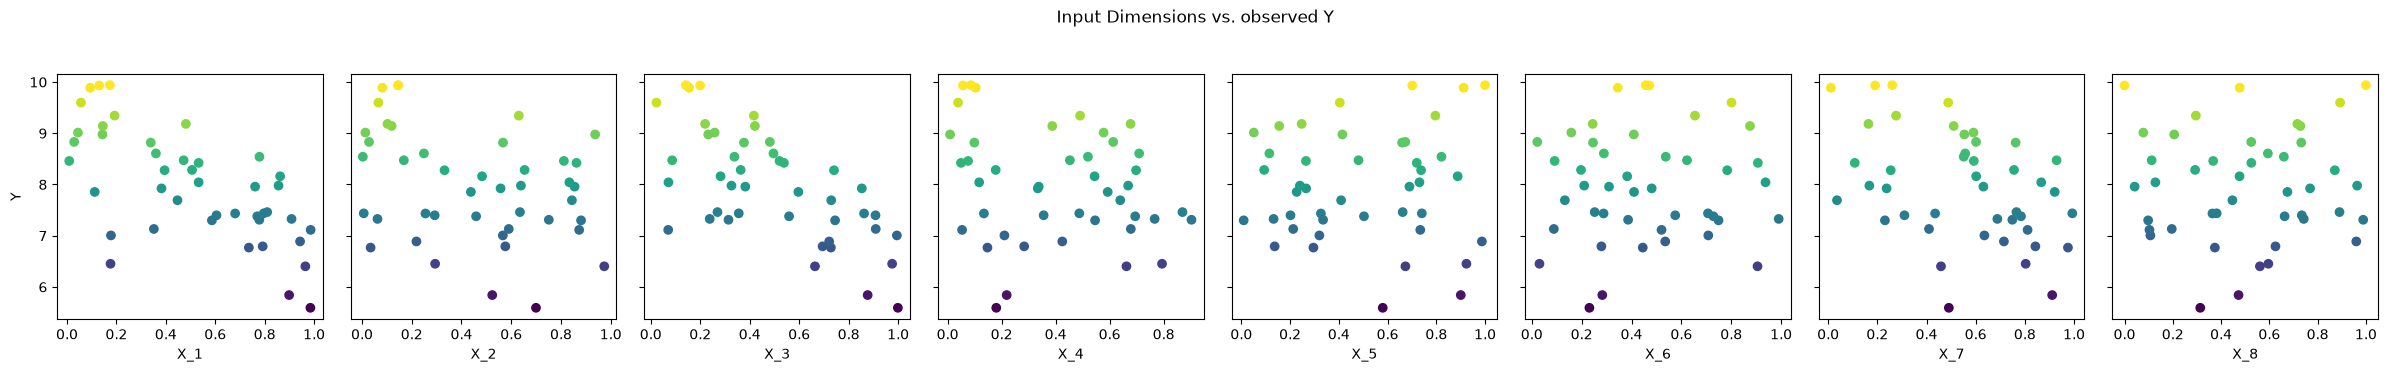

In [26]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['Y'], c = df['Y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('Y')
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.tight_layout()
plt.show()

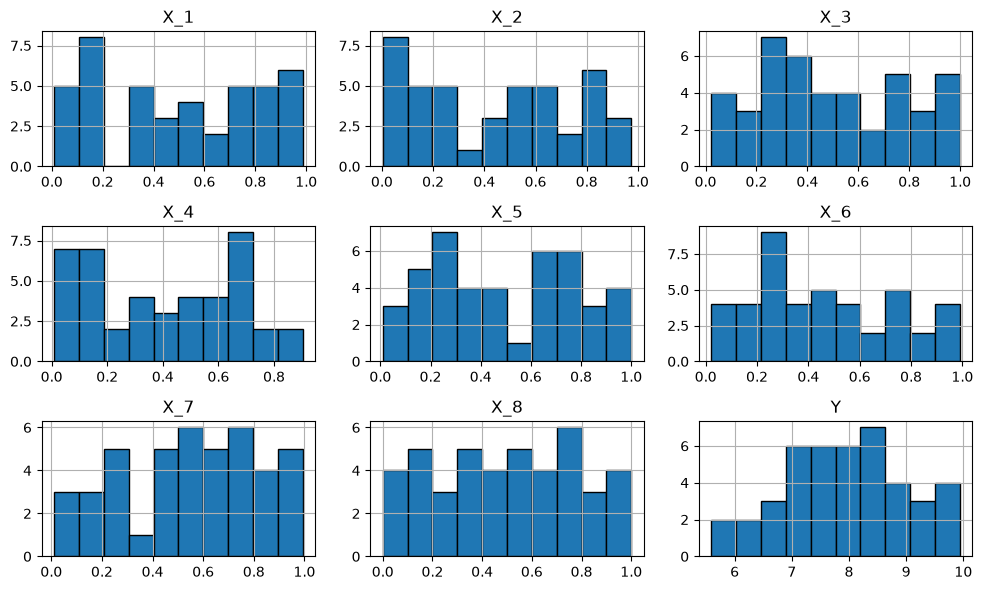

In [28]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [30]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with y:

 corr(X_1, Y) = -0.6751831977837723
 corr(X_2, Y) = -0.3398450518322521
 corr(X_3, Y) = -0.6691109278400792
 corr(X_4, Y) = -0.228794277458251
 corr(X_5, Y) = 0.044071076392128136
 corr(X_6, Y) = 0.040768368763048284
 corr(X_7, Y) = -0.4295707101581679
 corr(X_8, Y) = 0.03670420105555379


<Axes: >

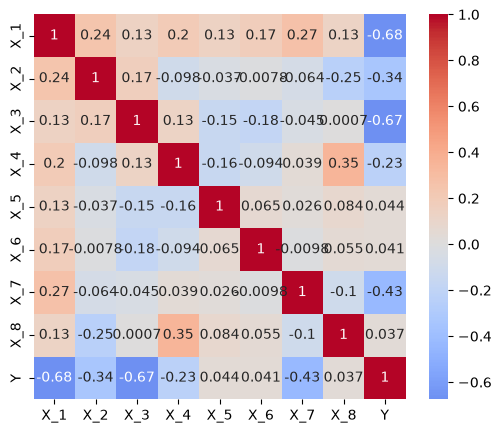

In [32]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

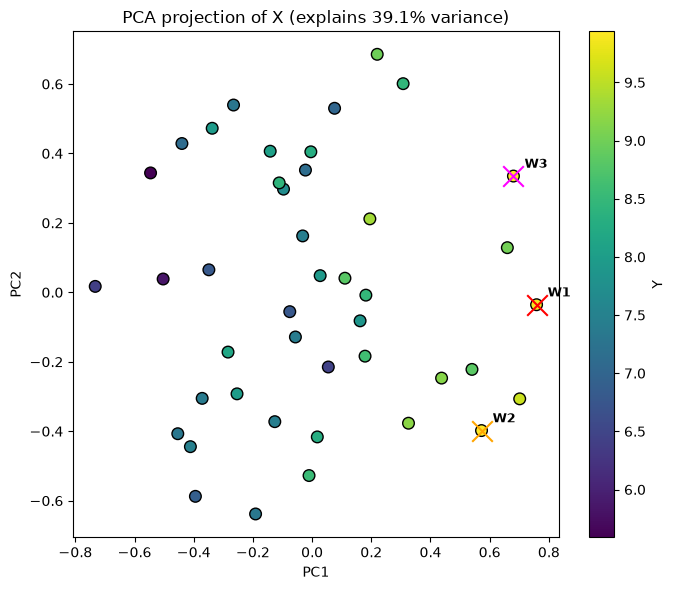

In [44]:
# Identify clustering of high-y points using PCA projection to 2D
pca            = PCA(n_components = 2)
X2             = pca.fit_transform(X)
fig, ax        = plt.subplots(figsize = (7, 6))

n_initial      = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   # e.g. 3 after Week 3 is appended
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

sc   = plt.scatter(X2[:, 0], X2[:, 1], c = Y, cmap = "viridis", s = 70, edgecolor = "k")

# Each week's query point: distinct marker/colour, annotated with its week number
markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

for wk in range(1, n_weeks_so_far + 1):
    mask = week_labels == wk
    ax.scatter(X2[mask, 0], X2[mask, 1], c = colors[(wk - 1) % len(colors)], s = 220, edgecolor = "k", linewidth=1.5
               , marker = markers[(wk - 1) % len(markers)], label = f"Week {wk} query", zorder = 5)
    for xi, yi in zip(X2[mask, 0], X2[mask, 1]):
        ax.annotate(f"W{wk}", (xi, yi), textcoords = "offset points", xytext = (8, 6),
                    fontsize=9, fontweight = "bold")

plt.colorbar(sc, ax = ax, label = "Y")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()
plt.show()

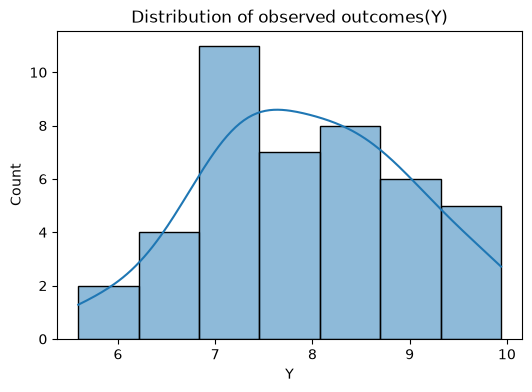

In [46]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process

In [49]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [52]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.17**2 * RBF(length_scale=[1.73, 2.45, 1.34, 2.4, 3.78, 2.5, 1.85, 100]) + WhiteKernel(noise_level=1e-08)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [56]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0    # Week 1

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.0367758  0.08940202 0.21038865 0.15722423 0.81773626 0.5591805
 0.10000647 0.84937986]
UCB Score: 9.994427e+00


# Week 2: Consolidated Bayesian Optimisation Function

In [59]:
def upper_confidence_bound(mu, sigma, beta = 2.0):
    """UCB(x) = mu(x) + beta * sigma(x). Higher beta => more exploration."""
    return mu + beta * sigma
    
def expected_improvement(mu, sigma, y_best, xi = 0.01):
    """EI(x) = E[max(f(x) - f(x_best) - xi, 0)]."""
    with np.errstate(divide = "warn"):
        improvement = mu - y_best - xi
        Z           = improvement / sigma
        ei          = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

def suggest_next_point( X_samples, y_samples, n_dims = 8, acquisition = "ucb", beta = 1.5,
                        xi = 0.01, n_restarts = 20, random_state = 42,
                        length_scale_bounds = (1e-2, 1e2), noise_bounds = (1e-8, 1e0)):

    rng    = np.random.default_rng(random_state)
    
    bounds = [(0.0, 0.999999)] * n_dims

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(n_dims), length_scale_bounds = length_scale_bounds) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = noise_bounds)
   
    gp     = GaussianProcessRegressor(kernel = kernel, normalize_y = False, n_restarts_optimizer = 10, random_state = random_state)
    
    gp.fit(X_samples, y_samples)

    y_best = y_samples.max()

    def acq_objective(x):
        x         = x.reshape(1, -1)    
        mu, sigma = gp.predict(x, return_std=True)
        
        if acquisition == "ei":
            val   = expected_improvement(mu, sigma, y_best, xi = xi)
        else:
            val   = upper_confidence_bound(mu, sigma, beta = beta)
        
        return - val[0]  # minimise the negative -> maximise the acquisition

    best_val = np.inf
    X_next   = None
    for _ in range(n_restarts):
        x0   = rng.uniform(0, 0.999999, n_dims)
        res  = minimize(acq_objective, x0, bounds = bounds, method = "L-BFGS-B")
        if res.fun < best_val:
            best_val = res.fun
            X_next   = res.x

    mu_next, sigma_next = gp.predict(X_next.reshape(1, -1), return_std = True)
    return X_next, gp, mu_next[0], sigma_next[0], - best_val


In [61]:
beta    = 1.5

X_next, gp_week2, mu_next, sigma_next, acq_val = suggest_next_point(  X, Y, n_dims = 8, acquisition = "ucb", 
                                                                      beta = beta, n_restarts = 20, random_state = 42
                                                                    )

print(f"Week 2 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean  : {mu_next:.4f}")
print(f"Predicted std   : {sigma_next:.4f}")
print(f"UCB acquisition : {acq_val:.4f}  (beta = {beta})")

Week 2 next query point: [0.087468 0.1383   0.138349 0.268046 0.880363 0.537263 0.175429 0.999999]
Predicted mean  : 9.9588
Predicted std   : 0.0386
UCB acquisition : 10.0167  (beta = 1.5)


# Week 3: Get Query Point

In [63]:
# lowered beta from 1.5 to 1.0
beta_week3 = 1.0  

X_next, gp_week3, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims = 8, acquisition = "ucb", beta = beta_week3, n_restarts = 20, random_state = 42
)

print(f"Week 3 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week3})")

Week 3 next query point: [0.099395 0.146876 0.151388 0.237139 0.871334 0.506745 0.182767 0.999999]
Predicted mean         : 9.9701
Predicted std          : 0.0296
UCB acquisition        : 9.9997  (beta = 1.0)


# Week 3: Perform Visualisation

In [65]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week3.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week3 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


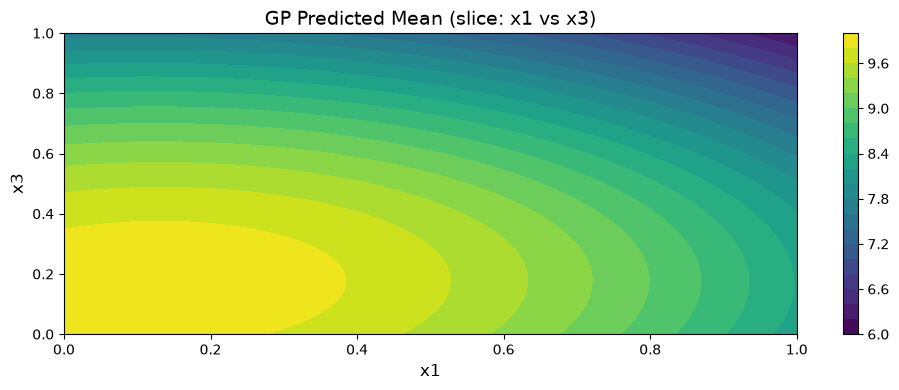

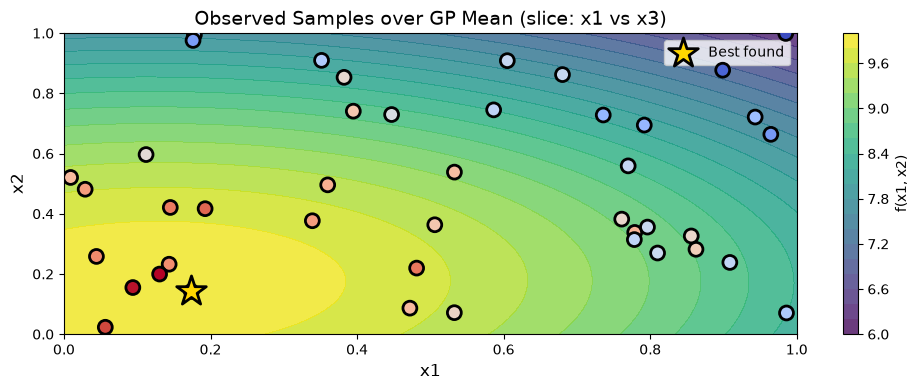

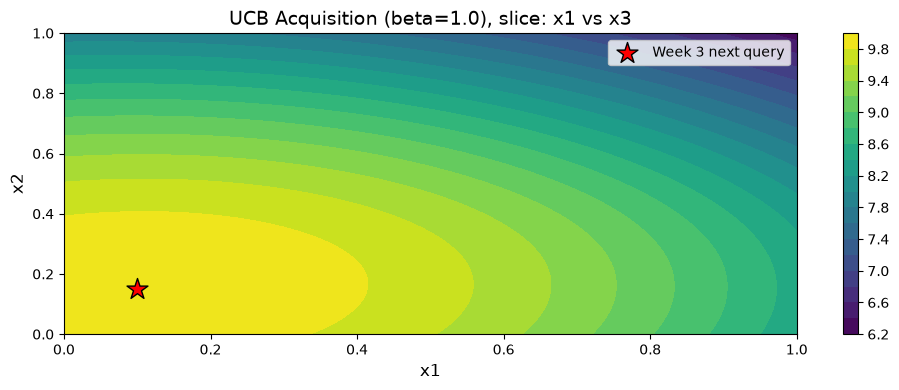

In [66]:
# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
plt.show()

# UCB acquisition surface with the Week 3 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week3}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 3 next query")
ax.legend()
plt.show()

# Week 4: Calling the consolidated Bayesian Function with lowered β( = 0.7 )

In [72]:
beta_week4 = 0.7   # lowered from Week 3's 1.0 -- see rationale above

X_next, gp_week4, mu_next, sigma_next, acq_val = suggest_next_point(
    X, Y, n_dims=8, acquisition="ucb", beta=beta_week4, n_restarts=20, random_state=42
)

print(f"Week 4 next query point: {np.round(X_next, 6)}")
print(f"Predicted mean         : {mu_next:.4f}")
print(f"Predicted std          : {sigma_next:.4f}")
print(f"UCB acquisition        : {acq_val:.4f}  (beta = {beta_week4})")

Week 4 next query point: [0.105972 0.149435 0.157841 0.220093 0.869536 0.490015 0.18591  0.999999]
Predicted mean         : 9.9739
Predicted std          : 0.0252
UCB acquisition        : 9.9915  (beta = 0.7)


# Perform Visualisation

In [75]:
# Identify the two most-correlated input dims (for slicing/plotting)
corrs      = np.array([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
top2       = np.argsort(-np.abs(corrs))[:2]
da, db     = int(top2[0]), int(top2[1])
print(f"Slicing through x{da+1} and x{db+1} (most correlated with Y)")

incumbent  = X[Y.argmax()].copy()

res_grid   = 60
grid_1d    = np.linspace(0, 1, res_grid)
A, B       = np.meshgrid(grid_1d, grid_1d)
pts        = np.tile(incumbent, (res_grid * res_grid, 1))
pts[:, da] = A.ravel()
pts[:, db] = B.ravel()

mu_grid, sigma_grid = gp_week4.predict(pts, return_std=True)
Z_mean    = mu_grid.reshape(res_grid, res_grid)
Z_ucb     = (mu_grid + beta_week4 * sigma_grid).reshape(res_grid, res_grid)

Slicing through x1 and x3 (most correlated with Y)


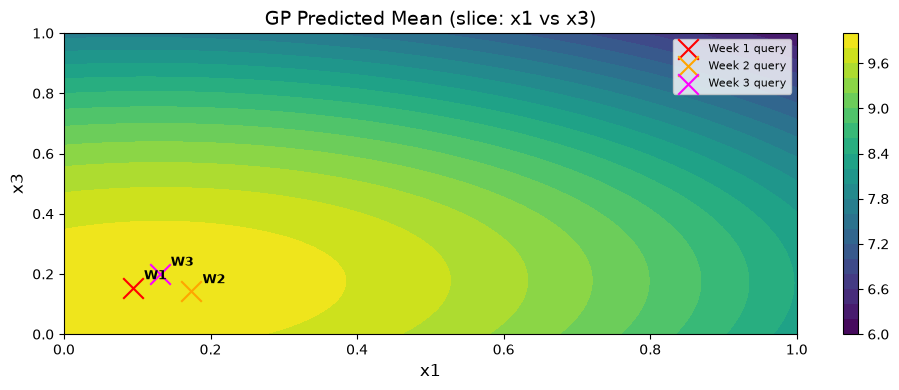

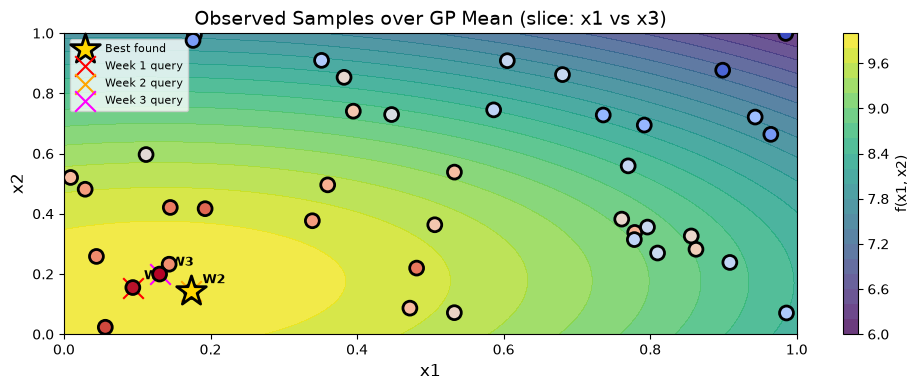

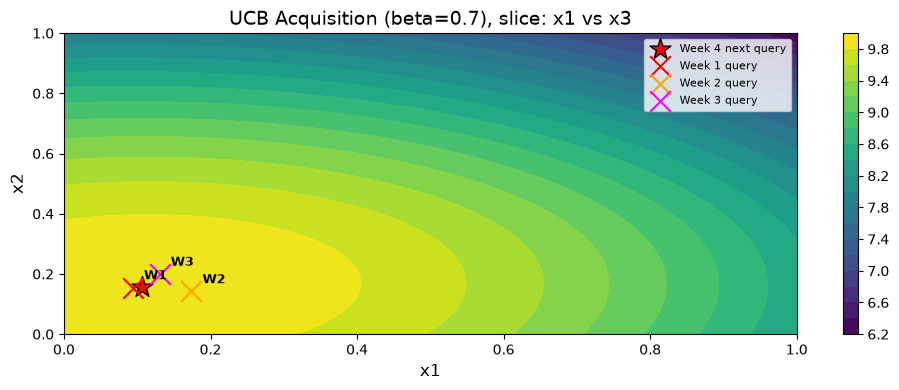

In [79]:
n_initial = len(X0)
n_weeks_so_far = X.shape[0] - n_initial   # e.g. 3 after Week 3 is appended
week_labels = np.array([0] * n_initial + list(range(1, n_weeks_so_far + 1)))

markers = ["x", "x", "x", "x", "x", "x", "x", "x"]
colors  = ["red", "orange", "magenta", "cyan", "lime", "brown", "gold", "deepskyblue"]

def highlight_weekly_points(ax, dim_a, dim_b):
    """Overlay each week's query point (columns dim_a, dim_b of X) on the given axes."""
    for wk in range(1, n_weeks_so_far + 1):
        mask = week_labels == wk
        ax.scatter(X[mask, dim_a], X[mask, dim_b], c=colors[(wk - 1) % len(colors)], s=220,
                   edgecolor="k", linewidth=1.5, marker=markers[(wk - 1) % len(markers)],
                   label=f"Week {wk} query", zorder=6)
        for xi, yi in zip(X[mask, dim_a], X[mask, dim_b]):
            ax.annotate(f"W{wk}", (xi, yi), textcoords="offset points", xytext=(8, 6),
                        fontsize=9, fontweight="bold", zorder=7)


# GP predicted mean surface (using plotting_utils.plot_2d_function)
fig, ax = plot_2d_function(A, B, Z_mean, title=f"GP Predicted Mean (slice: x{da+1} vs x{db+1})")
ax.set_xlabel(f"x{da+1}"); ax.set_ylabel(f"x{db+1}")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# Observed samples overlaid on the GP mean surface (using plotting_utils.plot_2d_bo_state)
fig, ax = plot_2d_bo_state(A, B, Z_mean, X[:, [da, db]], Y,
                            title=f"Observed Samples over GP Mean (slice: x{da+1} vs x{db+1})")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

# UCB acquisition surface with the Week 4 query point marked
fig, ax = plot_2d_function(A, B, Z_ucb, title=f"UCB Acquisition (beta={beta_week4}), slice: x{da+1} vs x{db+1}")
ax.scatter(X_next[da], X_next[db], marker="*", c="red", s=250, edgecolor="k", label="Week 4 next query")
highlight_weekly_points(ax, da, db)
ax.legend(fontsize=8)
plt.show()

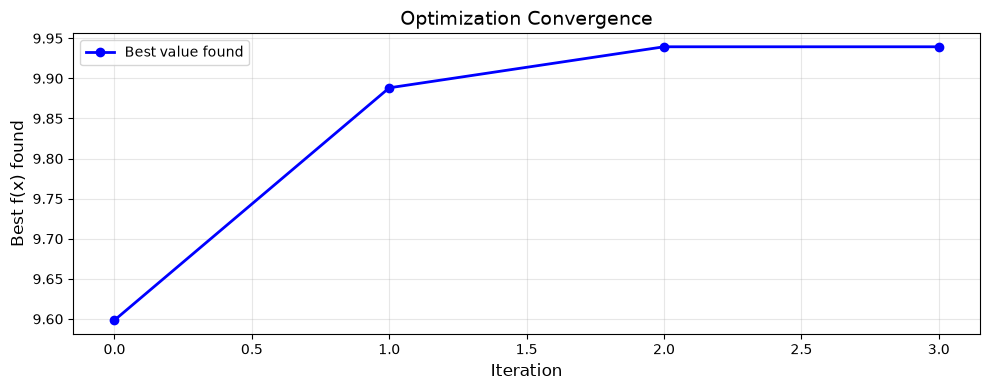

Best after Week 0 (initial data): 9.598482
Best after Week 1:                9.888207
Best after Week 2:                9.939383
Best after Week 3:                9.939383


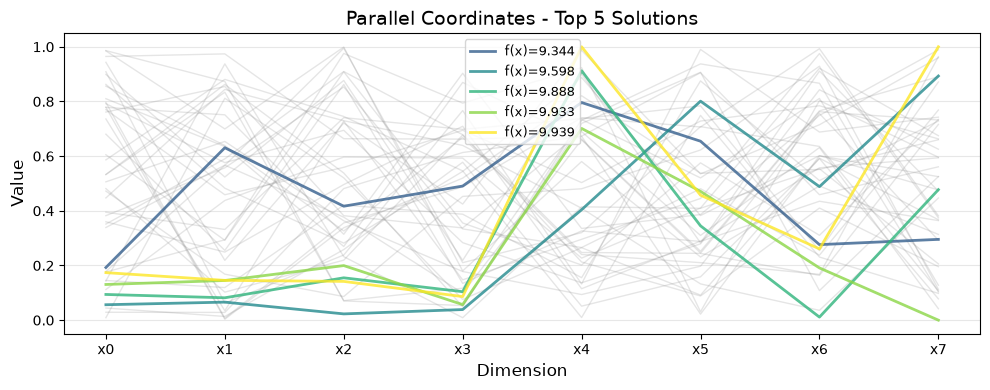

In [81]:
# Convergence: best value found at the end of each week
best_week0 = Y0.max()                                    # best of the original 40 points
best_week1 = max(best_week0, Y_w1_new_point[0])
best_week2 = max(best_week1, Y_w2_new_point[0])
best_week3 = Y.max()                                      # best after appending W1+W2+W3

plot_convergence([0, 1, 2, 3], [best_week0, best_week1, best_week2, best_week3])
plt.show()

print(f"Best after Week 0 (initial data): {best_week0:.6f}")
print(f"Best after Week 1:                {best_week1:.6f}")
print(f"Best after Week 2:                {best_week2:.6f}")
print(f"Best after Week 3:                {best_week3:.6f}")

# Parallel coordinates: how do the top 5 solutions compare across all 8 dimensions?
plot_parallel_coordinates(X, Y, n_best=5)
plt.show()

# Portal Submission 

In [86]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(X_next)
print("Points to be submitted(Week 1):",'0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351')
print("Points to be submitted(Week 2):",'0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999')
print("Points to be submitted(Week 3):", '0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000')
print(f"Points to be submitted(Week 4): {submission_str}")

Points to be submitted(Week 1): 0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
Points to be submitted(Week 2): 0.173855-0.145601-0.141754-0.086242-0.999999-0.457141-0.260715-0.999999
Points to be submitted(Week 3): 0.130530-0.145043-0.199622-0.056929-0.701352-0.471131-0.191028-0.000000
Points to be submitted(Week 4): 0.105972-0.149435-0.157841-0.220093-0.869536-0.490015-0.185910-0.999999
